#### (번외)불량 유형별 예측

In [ ]:
# y: Defects 그룹 전체 (멀티라벨)
#y_cols = [c for c in df.columns if c[0] == 'Defects']
#y = df[y_cols].astype(int)

# X: Process + Sensor 
#X = df[[c for c in df.columns if c[0] in ('Process', 'Sensor')]].copy()
#X = X.drop(columns=[('Process', 'id')], errors='ignore')
#X = X.drop(columns=[('Process', 'Product_Type')], errors='ignore')

#print("X:", X.shape, "y:", y.shape)
#print("y columns (first 10):", y.columns[:10].tolist())

# 환경설정하기

In [21]:
# 라이브러리 Import
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("="*60)


라이브러리 로드 완료!


### 데이터 로드

In [22]:
df1 = pd.read_csv("../../data/product_type_1.csv", header=[0, 1])
df = df.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   2653 non-null   int64  
 1   (Process, Product_Type)         2653 non-null   int64  
 2   (Process, Shot)                 2653 non-null   int64  
 3   (Process, Velocity_1)           2653 non-null   float64
 4   (Process, Velocity_2)           2653 non-null   float64
 5   (Process, Velocity_3)           2653 non-null   float64
 6   (Process, High_Velocity)        2653 non-null   float64
 7   (Process, Cylinder_Pressure)    2653 non-null   int64  
 8   (Process, Rapid_Rise_Time)      2653 non-null   float64
 9   (Process, Biscuit_Thickness)    2653 non-null   int64  
 10  (Process, Clamping_Force)       2653 non-null   int64  
 11  (Process, Cycle_Time)           2653 non-null   float64
 12  (Process, Pressure_Rise_Time)   2653 non-null

## 불량 여부 이진 분류

### 타겟 | ('Defect_Flag','Is_Defect')

In [23]:
print("결측치 상위:\n", df.isnull().sum().sort_values(ascending=False).head(10))

print("\n불량 비율:\n", df[('Defect_Flag','Is_Defect')].value_counts(normalize=True))

결측치 상위:
 Process  id                   0
         Product_Type         0
         Shot                 0
         Velocity_1           0
         Velocity_2           0
         Velocity_3           0
         High_Velocity        0
         Cylinder_Pressure    0
         Rapid_Rise_Time      0
         Biscuit_Thickness    0
dtype: int64

불량 비율:
 (Defect_Flag, Is_Defect)
0    0.782887
1    0.217113
Name: proportion, dtype: float64


In [32]:
y = df[('Defect_Flag','Is_Defect')] # Is_Defect > defect 불량 유무

X = df[['Process','Sensor']].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape)
print("test:", X_test.shape)

print("train 불량률:", y_train.mean())
print("test 불량률:", y_test.mean())

print("")
print("="*60)
print(f"데이터 분포 유지됨")

print(f"랜덤 split이 잘 됨")

print(f"모델 평가 신뢰도 높음")
print("="*60)


train: (2122, 31)
test: (531, 31)
train 불량률: 0.2172478793590952
test 불량률: 0.21657250470809794

데이터 분포 유지됨
랜덤 split이 잘 됨
모델 평가 신뢰도 높음


In [29]:
print("결측치 개수 합계:", X_train.isnull().sum().sum()) # train_set.isnull().sum().sum()

print("="*60)
print("결측치 없음!")
print("="*60)

결측치 개수 합계: 0
결측치 없음!


In [33]:
X_train.dtypes

Process  id                        int64
         Product_Type              int64
         Shot                      int64
         Velocity_1              float64
         Velocity_2              float64
         Velocity_3              float64
         High_Velocity           float64
         Cylinder_Pressure         int64
         Rapid_Rise_Time         float64
         Biscuit_Thickness         int64
         Clamping_Force            int64
         Cycle_Time              float64
         Pressure_Rise_Time      float64
         Casting_Pressure          int64
         Spray_Time              float64
         Spray_1_Time            float64
         Spray_2_Time            float64
Sensor   Melting_Furnace_Temp    float64
         Air_Pressure            float64
         Air_Pressure_Min          int64
         Air_Pressure_Max          int64
         Coolant_Temp            float64
         Coolant_Temp_Min          int64
         Coolant_Temp_Max          int64
         Coolant

## X Train data 정보 확인

In [34]:
print(X_train.shape)
print(X_train.info())


(2122, 31)
<class 'pandas.DataFrame'>
Index: 2122 entries, 528 to 1791
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   2122 non-null   int64  
 1   (Process, Product_Type)         2122 non-null   int64  
 2   (Process, Shot)                 2122 non-null   int64  
 3   (Process, Velocity_1)           2122 non-null   float64
 4   (Process, Velocity_2)           2122 non-null   float64
 5   (Process, Velocity_3)           2122 non-null   float64
 6   (Process, High_Velocity)        2122 non-null   float64
 7   (Process, Cylinder_Pressure)    2122 non-null   int64  
 8   (Process, Rapid_Rise_Time)      2122 non-null   float64
 9   (Process, Biscuit_Thickness)    2122 non-null   int64  
 10  (Process, Clamping_Force)       2122 non-null   int64  
 11  (Process, Cycle_Time)           2122 non-null   float64
 12  (Process, Pressure_Rise_Time)   2122 

In [36]:
display(X_train.describe())

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  2.122000e+03       2122.0  2122.000000  2122.000000  2122.000000   
mean   1.752445e+06          1.0   545.798303     0.143168     0.168786   
std    1.250900e+06          0.0   356.067339     0.003815     0.004658   
min    1.000000e+00          1.0     1.000000     0.136000     0.162000   
25%    6.378942e+05          1.0   229.000000     0.142000     0.168000   
50%    1.510206e+06          1.0   519.500000     0.142000     0.168000   
75%    2.833482e+06          1.0   840.000000     0.144000     0.170000   
max    4.205745e+06          1.0  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  2122.000000   2122.000000       2122.000000     2122.000000   
mean      0.182214      2.135592        218.899152        0.008056   
std       0.006356      0.077473          8.113249        0.001481   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.178000      2.122000        215.000000        0.008000   
50%       0.182000      2.137000        217.000000        0.008000   
75%       0.186000      2.153000        218.000000        0.008000   
max       0.234000      2.285000        241.000000        0.021000   

                                                                        \
      Biscuit_Thickness Clamping_Force   Cycle_Time Pressure_Rise_Time   
count       2122.000000    2122.000000  2122.000000        2122.000000   
mean          11.658812     256.015551    21.364373           0.041761   
std            1.372763       2.249259     6.465165           0.003106   
min            0.000000     238.000000    20.300000           0.000000   
25%           11.000000     254.000000    20.700000           0.041000   
50%           12.000000     257.000000    20.900000           0.043000   
75%           12.000000     258.000000    21.100000           0.044000   
max           22.000000     263.000000   218.600000           0.046000   

                                                               \
      Casting_Pressure   Spray_Time Spray_1_Time Spray_2_Time   
count      2122.000000  2122.000000  2122.000000  2122.000000   
mean       1059.463713     8.235344     0.931008     0.790104   
std          39.149478     0.581471     0.145787     0.044352   
min         516.000000     7.000000     0.700000     0.700000   
25%        1039.000000     7.900000     0.800000     0.800000   
50%        1052.000000     8.000000     1.000000     0.800000   
75%        1054.000000     8.300000     1.000000     0.800000   
max        1164.000000    10.800000     1.200000     1.000000   

                    Sensor                                                 \
      Melting_Furnace_Temp Air_Pressure Air_Pressure_Min Air_Pressure_Max   
count           2122.00000  2122.000000           2122.0           2122.0   
mean             699.74557     6.129972              3.0              9.0   
std               13.66537     0.580223              0.0              0.0   
min              671.00000     4.600000              3.0              9.0   
25%              689.30000     5.800000              3.0              9.0   
50%              700.60000     6.200000              3.0              9.0   
75%              708.90000     6.600000              3.0              9.0   
max              730.00000     7.100000              3.0              9.0   

                                                                       \
      Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max Coolant_Pressure   
count  2122.000000           2122.0           2122.0      2122.000000   
mean     26.760933             10.0             50.0         2.709025   
std       0.471624              0.0              0.0         0.041896   
min      25.900000             1

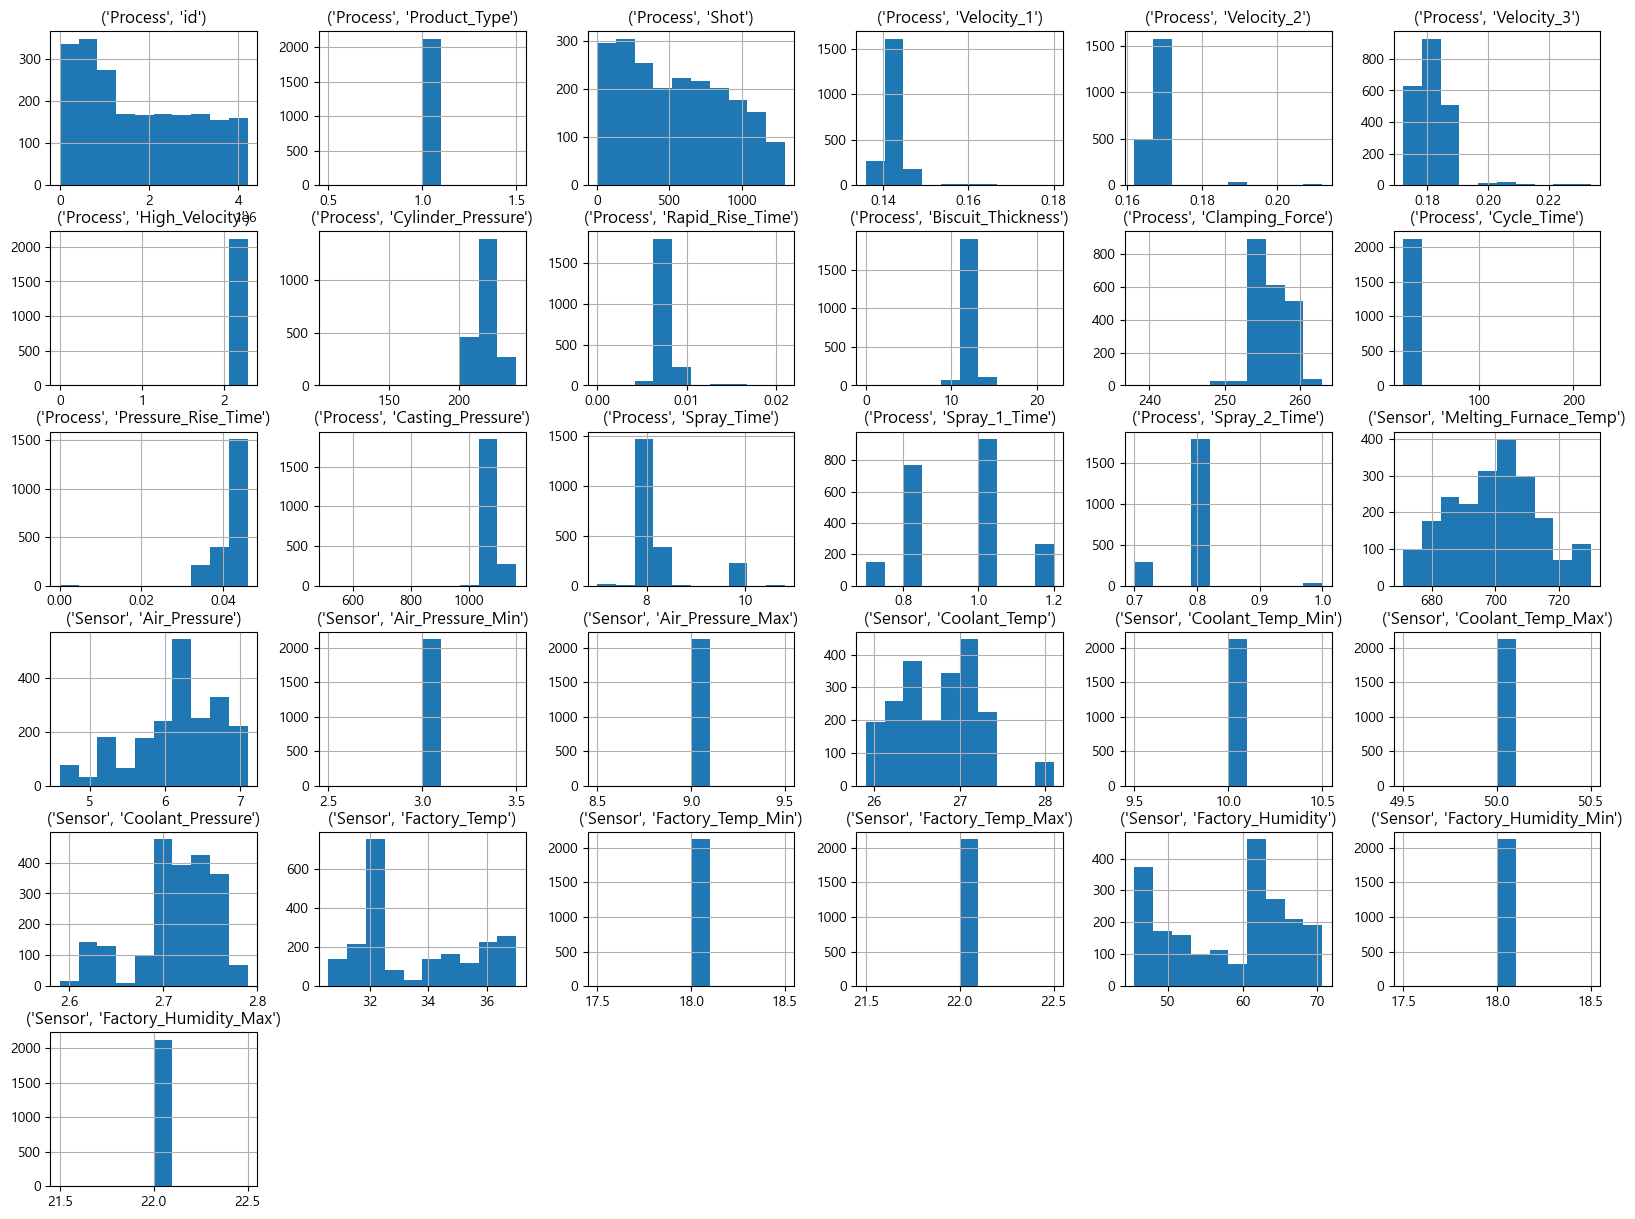

In [41]:
X_train.hist(figsize=(20,15))
plt.show()

#### feature 간 상관관계 - multicollinearity 확인

<Figure size 1200x1000 with 0 Axes>

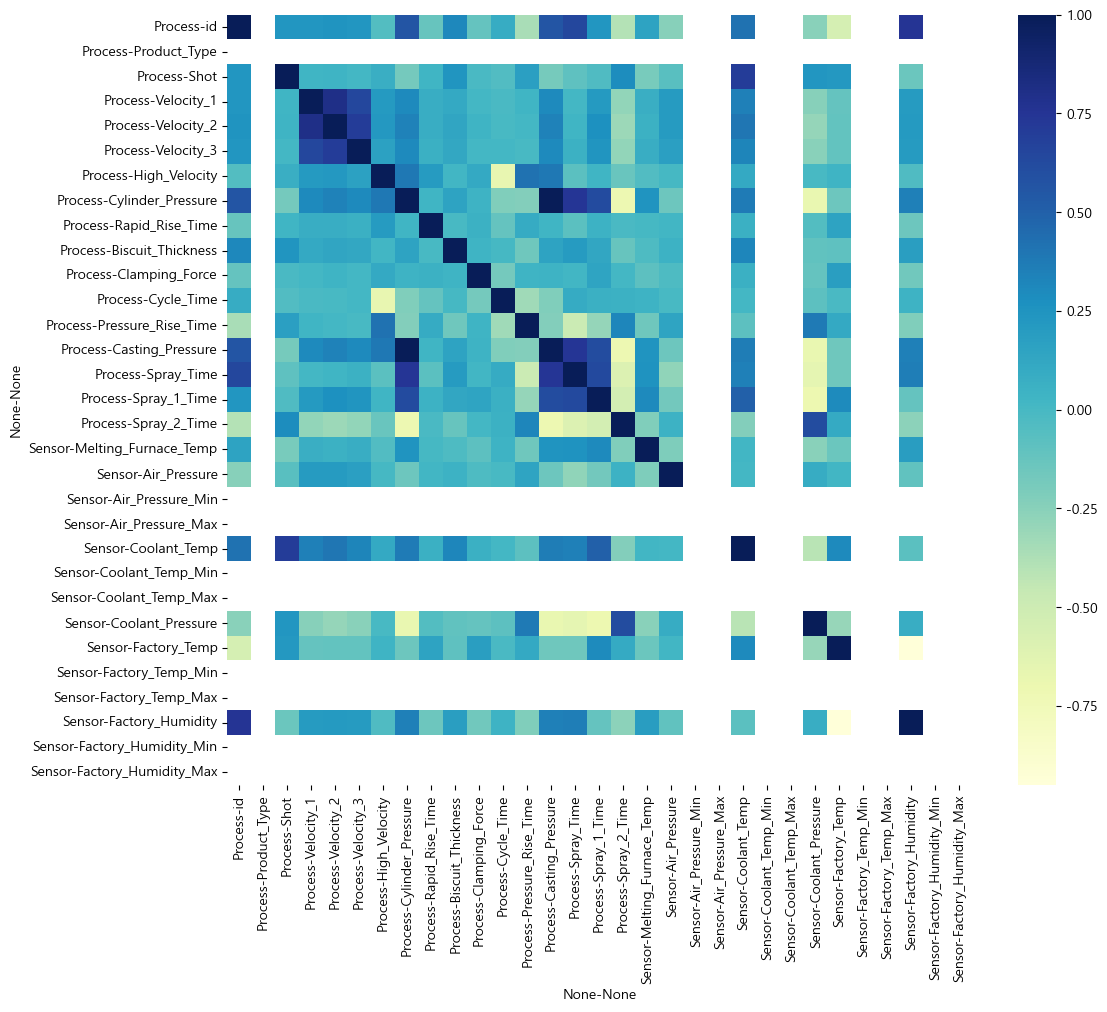

In [47]:
corr = X_train.corr()

plt.figure(figsize=(12,10))
corr = X_train.corr()

plt.figure(figsize=(12,10))
# one of the built‑in maps, e.g. YlGnBu, viridis, YlOrBr, …
sns.heatmap(corr, cmap="YlGnBu")
plt.show()
plt.show()

## y 타겟(불량) 분포 확인 

In [37]:
y_train.value_counts(normalize=True)

(Defect_Flag, Is_Defect)
0    0.782752
1    0.217248
Name: proportion, dtype: float64

Class imbalance 확인


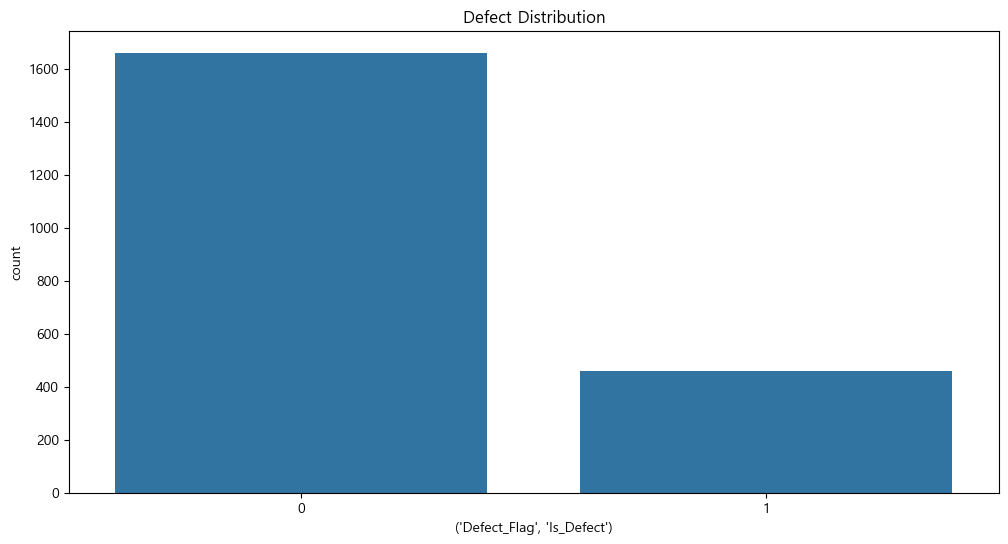

In [50]:
# 정상 불량 분포 확인하기


print("="*60)
print("Class imbalance 확인")
print("="*60)

sns.countplot(x=y_train)
plt.title("Defect Distribution")
plt.show()



### 간단한 RandomForest로 중요 변수 확인해보기

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

Process  id                      0.126743
         Shot                    0.093791
Sensor   Factory_Humidity        0.078509
Process  High_Velocity           0.071792
Sensor   Melting_Furnace_Temp    0.071591
         Factory_Temp            0.052833
Process  Velocity_3              0.052702
         Casting_Pressure        0.050614
Sensor   Coolant_Pressure        0.050211
         Air_Pressure            0.043703
dtype: float64